In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install -U ultralytics sahi supervision opencv-python gdown

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.2/87.2 kB 6.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 112.3/112.3 kB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.2/207.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 114.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 92.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 61.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
  

In [3]:
import os
from google.colab import files


In [51]:
import datetime
import shutil

uploaded = files.upload()
image_filename = list(uploaded.keys())[0]

timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')

drive_image_path = f"/content/drive/MyDrive/input_{timestamp}_{image_filename}"
output_image_name = f"prediction_{timestamp}_{image_filename.split('.')[0]}"
output_image_path = f"/content/drive/MyDrive/{output_image_name}.png"

shutil.copy(image_filename, drive_image_path)

Saving UAVDT_09.jpg to UAVDT_09.jpg


'/content/drive/MyDrive/input_20250801_143253_UAVDT_09.jpg'

In [56]:
user_prompts = input("Enter class names (separated with comma):  ")
category_names = [x.strip() for x in user_prompts.split(",") if x.strip() != ""]

Enter class names (separated with comma):  street light


In [57]:
from ultralytics import YOLOWorld
from sahi.predict import get_prediction, get_sliced_prediction, predict
from sahi import AutoDetectionModel
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from collections import Counter

model_path = "/content/drive/MyDrive/yolov8l-worldv2.pt"
model = YOLOWorld(model_path)
model.set_classes(category_names)

detection_model = AutoDetectionModel.from_pretrained(
    model_type='ultralytics',
    model=model,
    confidence_threshold=0.25,
    device='cuda:0',
)





In [58]:
result = get_sliced_prediction(
    drive_image_path,
    detection_model,
    slice_height = 256,
    slice_width = 256,
    overlap_height_ratio = 0.3,
    overlap_width_ratio = 0.3

)



Performing prediction on 18 slices.


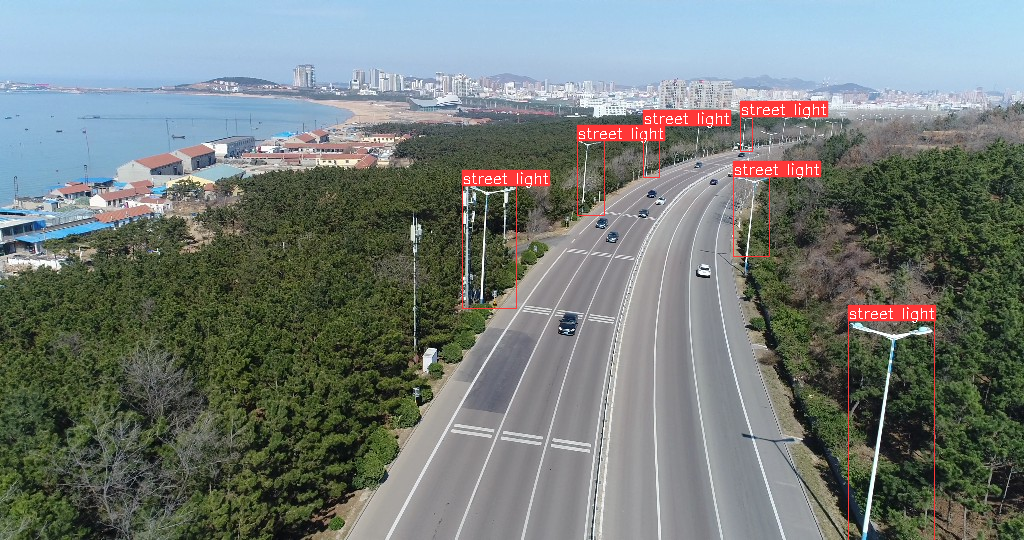


Detected Object Counts:
street light: 6


In [59]:
from PIL import Image
import cv2
from google.colab.patches import cv2_imshow
from collections import Counter

result.export_visuals(
    export_dir="/content/drive/MyDrive/",
    text_size=0.5,  # Size of the class label text
    rect_th=1,      # Thickness of bounding box lines
    hide_labels=False,  # Set True to hide class labels
    hide_conf=True,    # Set True to hide confidence scores
    file_name=output_image_name,

)

img = cv2.imread(output_image_path)
cv2_imshow(img)

class_names = [pred.category.name for pred in result.object_prediction_list]
class_counts = Counter(class_names)

print("\nDetected Object Counts:")
for cls, count in class_counts.items():
    print(f"{cls}: {count}")
